# PFC — Encoding bias: time vs goal progress

Coordinating notebook for the **encoding-bias** package. It runs four analyses
that together adjudicate whether PFC neurons encode *elapsed time* or
*goal progress*, and check that the answer is not an artefact of how the
behavioural variables were binned.

**The concern.** In `glm_analysis_v2`, `time_*` and `distance_*` are quantile-binned
(deciles) while `goal_progress` is equal-width. Quantile binning concentrates a
variable's resolution where its samples are dense, giving it more effective
flexibility. Because time, distance and goal progress are collinear within a leg,
that asymmetry can let time/distance soak up variance that genuinely belongs to
goal progress — biasing GP-tuned cells toward apparent time/distance encoding.
This is compounded by (a) the CPD being computed **in-sample** and (b) the
within-leg **collinearity** of the frames.

**The package (in order of evidential weight).**
1. **Ground-truth simulation** (`encoding_bias_simulation`) — synthesise neurons with
   known tuning and measure how much CPD is *misattributed* under each binning scheme.
2. **Cross-validated CPD across schemes** (`glm_cv_cpd`) — is the descriptive
   time-vs-GP ordering stable once binning is flexibility-fair *and* cross-validated?
3. **De-circularised peak-binning** (`tuning_peak_binning`) — the PI's data-adaptive
   bins, scored without double-dipping.
4. **OOD dissociation** (`time_vs_progress_dissociation`) — the **decisive** test:
   train on short legs, predict held-out long legs. Only duration variability breaks
   the collinearity, so this is what actually adjudicates time vs progress.

See `ENCODING_BIAS.md` for the full rationale.


In [ ]:
"""
For Yiying - preprocessing code to get from raw neuron activity to normalised firing rate matrices in trial progress bins.
assumes you have Trial_times and Neuron_raw arrays for a session, and that Trial_times is an array of shape (num_trials, num_states)
 with the time indices for each state transition in the trial, and Neuron_raw is an array of shape (num_neurons, total_time_points) with the raw firing rates of each neuron at each time point.

 
Important!!!
Your data should be truncates so that the first timebin of the ephys data is aligend to the first A
so trial 1 state a is 0 in trial_times. First column of the neural array should be the firing rate at time 0, which is the start of state A in trial 1. 
This way, when we partition the neural data using the trial times, we will get the correct segments of neural activity corresponding to each state in each trial.
"""

import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import zscore, sem, entropy



def partition(alist, indices):
    """
    Partitions a list into sublists based on a list of indices.
    Returns a numpy array of the sublists with dtype=object to handle varying lengths.
    """
    return np.asarray([np.asarray(alist[i:j]) for i, j in zip(indices[:-1], indices[1:])], dtype=object)

def unroll_listoflists(l):
    flat_list = [item for sublist in l for item in sublist]
    return(flat_list)

def smooth_circ(xx, sigma=10, axis=0):
    x_smoothed = gaussian_filter1d(np.hstack((xx, xx, xx)), sigma, axis=axis)[
        len(xx) : int(len(xx) * 2)
    ]
    return x_smoothed
def std_err(data_neuron):
    return smooth_circ(sem(data_neuron, axis=0))


num_trials=len(Trial_times)
num_neurons=len(Neuron_raw)

num_bins=90
num_states=4


Trial_times_conc=np.hstack((np.concatenate(Trial_times[:,:-1]),Trial_times[-1,-1])).astype(int)
Neurons_norm=np.zeros((num_neurons,num_trials,num_bins*num_states))
Neurons_norm[:]=np.nan

for neuron in np.arange(num_neurons):
    Neuron_raw_neuron=Neuron_raw[neuron,:]
    Neuron_raw_neuron_split=partition(list(Neuron_raw_neuron), list(Trial_times_conc))
    Neuron_raw_neuron_split_norm=np.asarray([normalise(Neuron_raw_neuron_split[ii])\
                                            for ii in np.arange(len(Neuron_raw_neuron_split))])
    Neuron_norm=(Neuron_raw_neuron_split_norm.reshape(len(Neuron_raw_neuron_split_norm)//4,\
                                                    len(Neuron_raw_neuron_split_norm[0])*4))
    
    Neurons_norm[neuron]=Neuron_norm
    
Mean_norm = np.mean(Neuron_norm, axis=0)

Smoothed_norm = smooth_circ(Mean_norm)

Std_err_smooth= std_err(Neuron_norm)

############################################
# -------- POLAR PLOTTING CODE -------- #
############################################

# Total bins across full trial
total_bins = num_bins * num_states

# Circular angles for plotting
angles = np.linspace(0, 2 * np.pi, total_bins, endpoint=False)

for neuron_idx in range(num_neurons):


    neuron_data = Smoothed_norm[neuron_idx]

    error = Std_err_smooth[neuron_idx]


    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="polar")

    ax.plot(angles, neuron_data, linewidth=2)
    ax.fill_between(angles, neuron_data - error, neuron_data + error, alpha=0.3)

    # Optional: mark state boundaries
    state_boundaries = np.arange(0, total_bins, num_bins)
    for sb in state_boundaries:
        ax.plot(
            [angles[sb], angles[sb]],
            [0, np.nanmax(neuron_data)],
            linestyle="--",
            linewidth=1,
        )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(f"Neuron {neuron_idx} Polar Firing Rate", fontsize=14)

    plt.tight_layout()
    plt.show()

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload

sys.path.insert(0, os.getcwd())
import glm_analysis_v2 as glm
import glm_cv_cpd as cv
import encoding_bias_simulation as sim
import tuning_peak_binning as pk
import time_vs_progress_dissociation as tvp
import time_vs_progress_report as rep
for m in (glm, cv, sim, pk, tvp, rep):
    reload(m)

glm.apply_gridmaze_style()
REGION = 'PFC'


In [2]:
from glm_analysis_v2 import build_data_dic_from_pfc
DATA_FOLDER = '/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/mFC_data/data'
META = os.path.join(DATA_FOLDER, 'MetaData')
mouse_recdays = [str(mr) for mr in np.load(os.path.join(META, 'combined_ABCDonly_days.npy'))]
data_dic = build_data_dic_from_pfc(DATA_FOLDER, mouse_recdays)
mouse_recdays = sorted(data_dic.keys())
print(f'{len(mouse_recdays)} {REGION} recdays loaded')


  ab03_01092023_02092023: 7 sessions
  ab03_05092023_06092023: 8 sessions
  ab03_29082023_30082023: 9 sessions
  ah03_12082021_13082021: 8 sessions
  ah03_18082021_19082021: 8 sessions
  ah04_01122021_02122021: 8 sessions
  ah04_05122021_06122021: 8 sessions
  ah04_07122021_08122021: 8 sessions
  ah04_09122021_10122021: 8 sessions
  ah04_14122021_16122021: 8 sessions
  ah07_01092023_02092023: 7 sessions
  ah07_27082023_28082023: 7 sessions
  ah07_29082023_30082023: 7 sessions
  me08_06092021_09092021: 8 sessions
  me08_10092021_11092021: 6 sessions
  me08_12092021_13092021: 7 sessions
  me10_09122021_10122021: 9 sessions
  me10_14122021_15122021: 6 sessions
  me10_17122021_19122021: 8 sessions
  me10_20122021_21122021: 6 sessions
  me11_01122021_02122021: 8 sessions
  me11_05122021_06122021: 9 sessions
  me11_07122021_08122021: 8 sessions
  me11_09122021_10122021: 9 sessions
  me11_12122021_13122021: 9 sessions
25 PFC recdays loaded


In [3]:
# Transition-duration filter. The later "*_filtered" GLM sections in
# LEC_glm_tuning_variables / PFC_glm_tuning_variables use 30 s; matching that keeps
# the CPD comparison apples-to-apples with the filtered GLM headline.
# NOTE the trade-off: the standalone dissociation notebook uses 60 s to maximise the
# leg-duration RANGE, which is what powers the OOD test (section 4). Raise this to 60
# if you want maximum OOD power at the cost of GLM comparability.
MAX_TRANSITION_SECONDS = 30
N_RECDAYS = len(mouse_recdays)                      # set to len(mouse_recdays) for the full run
TABLES = tvp.build_design_tables(mouse_recdays[:N_RECDAYS], data_dic,
                                 max_transition_seconds=MAX_TRANSITION_SECONDS)
rep_table = next(iter(TABLES.values()))   # one representative recday for sim / peak-binning
print('recdays in TABLES:', list(TABLES))


Building tables:   0%|          | 0/25 [00:00<?, ?it/s]

Building tables:   4%|▍         | 1/25 [00:01<00:41,  1.72s/it]

  ab03_01092023_02092023: 63 neurons x 24786 samples, 722 legs, has_hd=False


Building tables:   8%|▊         | 2/25 [00:03<00:38,  1.69s/it]

  ab03_05092023_06092023: 64 neurons x 18327 samples, 436 legs, has_hd=False


...

  me11_07122021_08122021: 24 neurons x 26955 samples, 818 legs, has_hd=False


Building tables:  96%|█████████▌| 24/25 [00:47<00:02,  2.87s/it]

  me11_09122021_10122021: 26 neurons x 24096 samples, 814 legs, has_hd=False


Building tables: 100%|██████████| 25/25 [00:49<00:00,  2.00s/it]

  me11_12122021_13122021: 12 neurons x 11778 samples, 308 legs, has_hd=False
recdays in TABLES: ['ab03_01092023_02092023', 'ab03_05092023_06092023', 'ab03_29082023_30082023', 'ah03_12082021_13082021', 'ah03_18082021_19082021', 'ah04_01122021_02122021', 'ah04_05122021_06122021', 'ah04_07122021_08122021', 'ah04_09122021_10122021', 'ah04_14122021_16122021', 'ah07_01092023_02092023', 'ah07_27082023_28082023', 'ah07_29082023_30082023', 'me08_06092021_09092021', 'me08_10092021_11092021', 'me08_12092021_13092021', 'me10_09122021_10122021', 'me10_14122021_15122021', 'me10_17122021_19122021', 'me10_20122021_21122021', 'me11_01122021_02122021', 'me11_05122021_06122021', 'me11_07122021_08122021', 'me11_09122021_10122021', 'me11_12122021_13122021']


## 1. Ground-truth simulation — is the binning biased?

Synthetic neurons are tuned to **exactly one** continuous variable (with the real
behavioural sampling), then pushed through the GLM design + CPD under several
schemes. The **misattribution matrix** has rows = true variable, columns =
regressor the CPD landed on. A perfectly unbiased pipeline is diagonal; off-diagonal
mass in the `time-*`/`dist-*` columns of the `GP(t)` row is the bias.

`glm_onehot` reproduces the current (mismatched) GLM; `matched_*` schemes encode
every continuous variable identically (flexibility-fair).


glm_onehot      : GP correct CPD=0.148  leaked->time/dist=0.005  frac correct=0.95
matched_linear  : GP correct CPD=0.161  leaked->time/dist=0.003  frac correct=0.96
matched_quantile: GP correct CPD=0.147  leaked->time/dist=0.005  frac correct=0.95


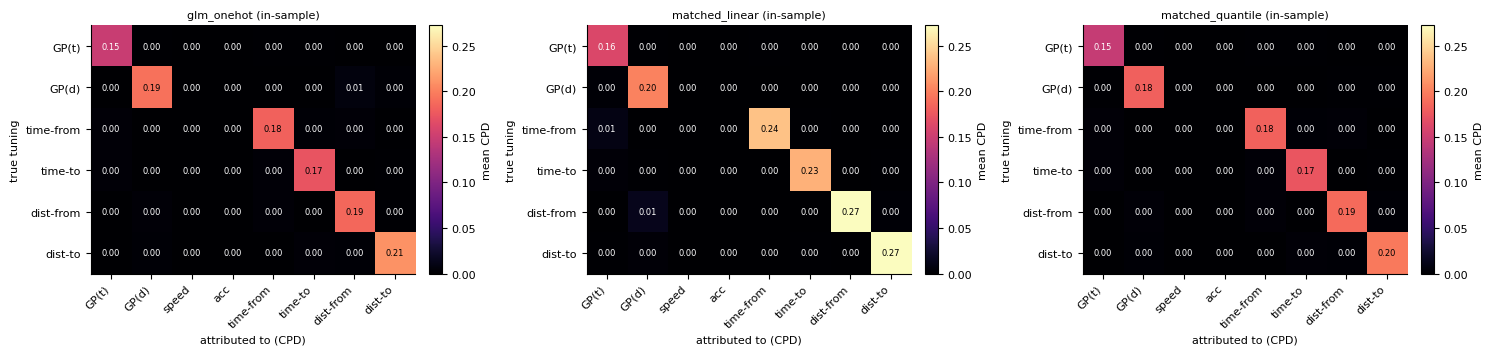

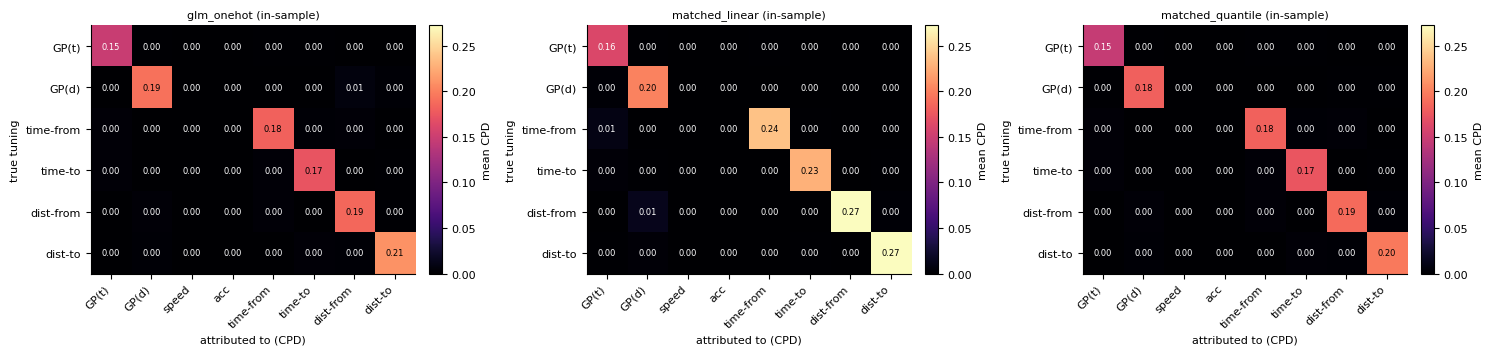

In [4]:
res_sim = sim.run_simulation(
    rep_table, schemes=('glm_onehot', 'matched_linear', 'matched_quantile'),
    cv_folds=0, n_per_cell=20, snr=1.0)
for sc in ('glm_onehot', 'matched_linear', 'matched_quantile'):
    lk = res_sim[sc]['leakage']['goal_progress']
    print(f"{sc:16s}: GP correct CPD={lk['correct_cpd']:.3f}  "
          f"leaked->time/dist={lk['leaked_to_time_distance']:.3f}  "
          f"frac correct={lk['fraction_correct']:.2f}")
res_sim['_figure']


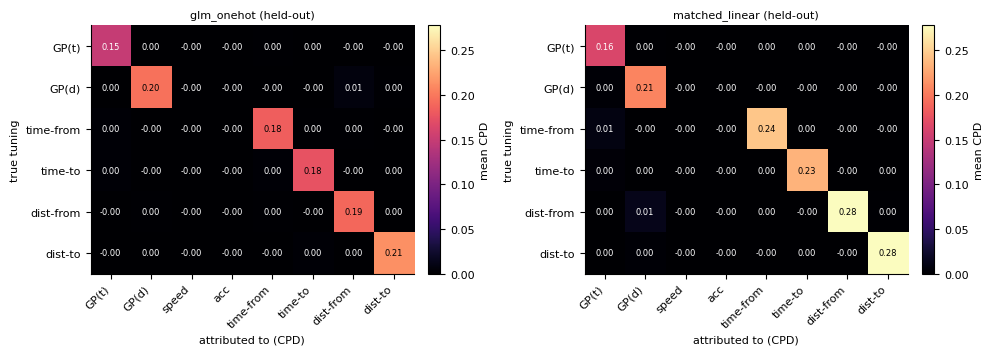

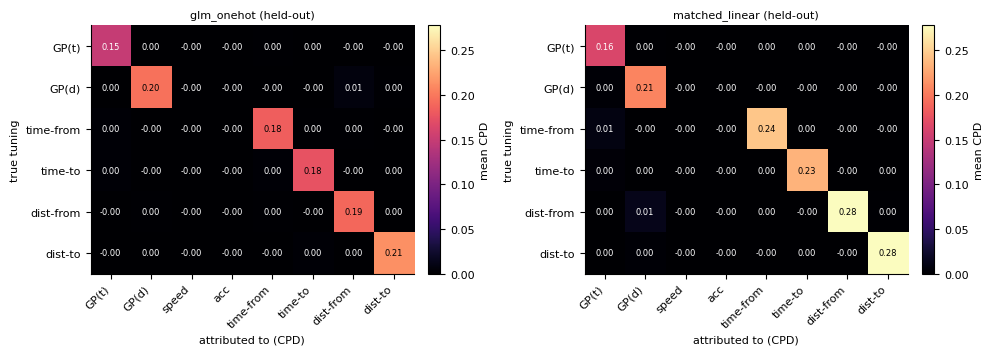

In [5]:
# Cross-validated version: held-out CPD removes the in-sample inflation.
res_sim_cv = sim.run_simulation(
    rep_table, schemes=('glm_onehot', 'matched_linear'),
    cv_folds=5, n_per_cell=15, snr=1.0)
res_sim_cv['_figure']


## 2. Cross-validated CPD across encoding schemes (robustness)

Real neurons now. If the descriptive `GP - time` contrast **flips sign** across
schemes, the original in-sample CPD ordering was a binning artefact and only the
OOD test (section 4) should be trusted. Stable bars => the descriptive result is
robust.



=== scheme: glm_onehot ===
  ab03_01092023_02092023: 63 neurons, median full-model held-out R^2 = 0.014
  ab03_05092023_06092023: 64 neurons, median full-model held-out R^2 = 0.015
  ab03_29082023_30082023: 70 neurons, median full-model held-out R^2 = 0.012
  ah03_12082021_13082021: 16 neurons, median full-model held-out R^2 = 0.023
  ah03_18082021_19082021: 15 neurons, median full-model held-out R^2 = 0.050
  ah04_01122021_02122021: 117 neurons, median full-model held-out R^2 = 0.006
  ah04_05122021_06122021: 114 neurons, median full-model held-out R^2 = 0.004
  ah04_07122021_08122021: 81 neurons, median full-model held-out R^2 = 0.002
  ah04_09122021_10122021: 99 neurons, median full-model held-out R^2 = 0.003
  ah04_14122021_16122021: 70 neurons, median full-model held-out R^2 = 0.003
  ah07_01092023_02092023: 97 neurons, median full-model held-out R^2 = 0.008
  ah07_27082023_28082023: 80 neurons, median full-model held-out R^2 = 0.007
  ah07_29082023_30082023: 72 neurons, median f

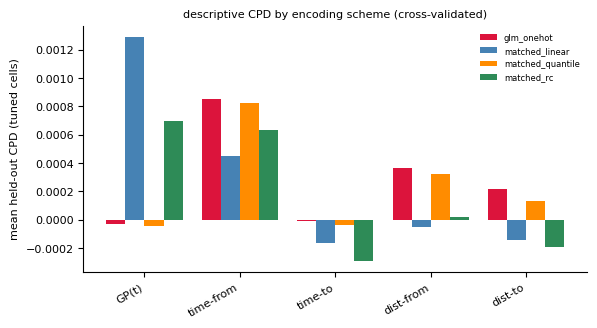

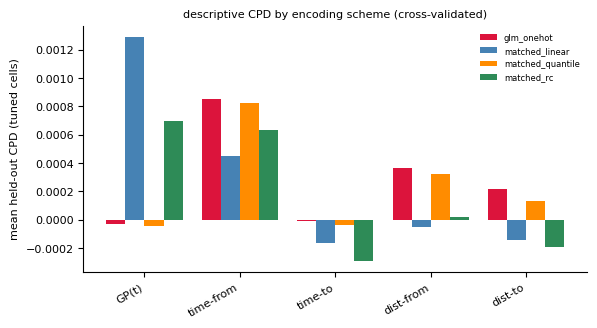

In [6]:
pooled_by_scheme, summary = rep.compare_schemes_cpd(
    TABLES, schemes=('glm_onehot', 'matched_linear', 'matched_quantile', 'matched_rc'),
    n_folds=5)
# Per-sample single-neuron held-out CPD is ~0 for untuned cells, so we summarise the
# TUNED subpopulation (full-model held-out R^2 > 0) plus the all-neuron mean.
for s in summary:
    print(f"{s['scheme']:16s}: tuned={s['frac_tuned']:.0%}  GP={s['GP_tuned']:.3f}  "
          f"time={s['time_tuned']:.3f}  dist={s['dist_tuned']:.3f}  "
          f"GP-time(tuned)={s['GP_minus_time_tuned']:+.3f}  "
          f"GP-time(mean)={s['GP_minus_time_mean']:+.4f}")
rep.plot_scheme_comparison(pooled_by_scheme)
plt.gcf()


## 3. peak-binning, de-circularised

Bins are placed where the **population tuning changes fastest** (robust to ramps),
derived on one half of the legs and scored on the other half — so no sample informs
both its own bins and its own CPD. The red lines show where resolution was placed;
the grey histogram is the PI's original 'peak' (argmax) distribution.


de-circularised peak-binning: median GP CPD=0.000  time CPD=-0.000  GP-time=+0.001


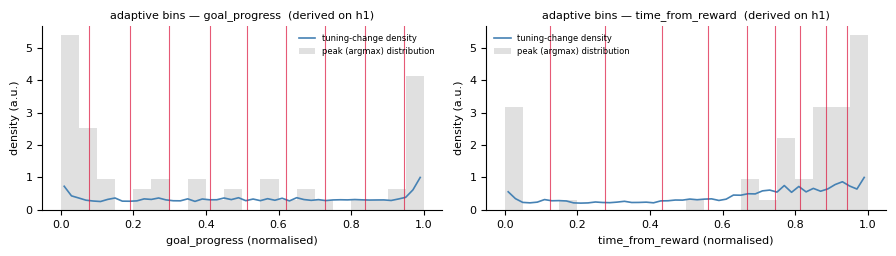

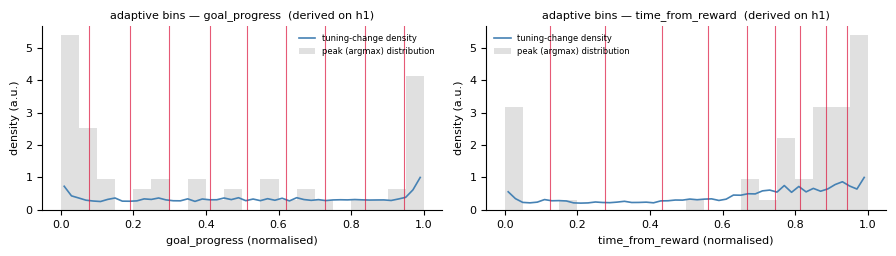

In [7]:
pb = pk.run_peak_binning(rep_table, n_bins=10, n_folds=5)
gp = np.nanmedian(pb['cpd']['goal_progress'])
tt = np.nanmedian(np.nanmax(np.vstack([pb['cpd']['time_from_reward'],
                                       pb['cpd']['time_to_reward']]), axis=0))
print(f"de-circularised peak-binning: median GP CPD={gp:.3f}  time CPD={tt:.3f}  GP-time={gp-tt:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 2.6))
pk.plot_adaptive_bins(pb['diag'], 'goal_progress', ax=axes[0], half='h1')
pk.plot_adaptive_bins(pb['diag'], 'time_from_reward', ax=axes[1], half='h1')
fig.tight_layout()
fig


## 4. Adjudicating test: OOD dissociation + full report

`build_report` runs the OOD dissociation (decisive) and assembles it with the
CPD-by-scheme robustness into one figure + printed headline. The OOD median delta
is the answer: **>0 leans elapsed time, <0 leans goal progress**.


OOD temporal/gaussian: 100%|██████████| 25/25 [07:44<00:00, 18.58s/it]



=== scheme: glm_onehot ===
  ab03_01092023_02092023: 63 neurons, median full-model held-out R^2 = 0.014
  ab03_05092023_06092023: 64 neurons, median full-model held-out R^2 = 0.015
  ab03_29082023_30082023: 70 neurons, median full-model held-out R^2 = 0.012
  ah03_12082021_13082021: 16 neurons, median full-model held-out R^2 = 0.023
  ah03_18082021_19082021: 15 neurons, median full-model held-out R^2 = 0.050
  ah04_01122021_02122021: 117 neurons, median full-model held-out R^2 = 0.006
  ah04_05122021_06122021: 114 neurons, median full-model held-out R^2 = 0.004
  ah04_07122021_08122021: 81 neurons, median full-model held-out R^2 = 0.002
  ah04_09122021_10122021: 99 neurons, median full-model held-out R^2 = 0.003
  ah04_14122021_16122021: 70 neurons, median full-model held-out R^2 = 0.003
  ah07_01092023_02092023: 97 neurons, median full-model held-out R^2 = 0.008
  ah07_27082023_28082023: 80 neurons, median full-model held-out R^2 = 0.007
  ah07_29082023_30082023: 72 neurons, median f

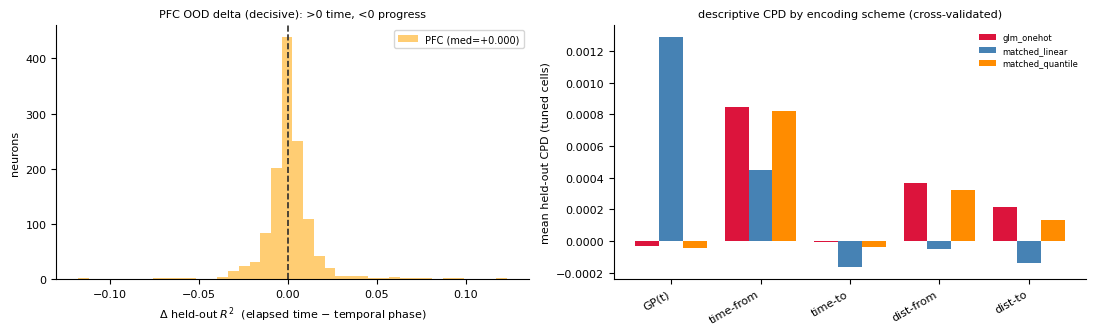

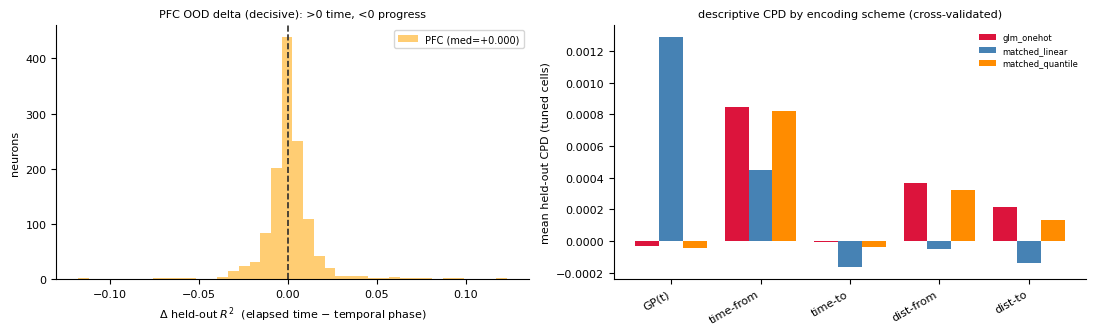

In [8]:
report = rep.build_report(
    TABLES, region=REGION, contrast='temporal',
    schemes=('glm_onehot', 'matched_linear', 'matched_quantile'),
    run_simulation=True, run_peak_binning=True, n_folds=5)
report['figure']


### How to read these results

- **OOD delta (section 4) is the verdict.** A median delta significantly >0 means
  cells generalise as *fixed-latency time* across durations; <0 means *goal progress*.
- **CPD-by-scheme (section 2) is descriptive.** Use it only to check robustness: if
  `GP - time` is stable across `glm_onehot` and the `matched_*` schemes, the
  descriptive ordering is not a binning artefact. If it flips, defer entirely to OOD.
- **Simulation (section 1)** tells you the *direction and size* of the binning bias
  for this dataset's sampling. Compare the `glm_onehot` matrix (expected off-diagonal
  GP->time leak) with the `matched_*` matrices (should be more diagonal).
- **Peak-binning (section 3)** implements the PI's idea without circularity; treat it
  as one more robustness scheme, not as the adjudicator.

Run the full set (`N_RECDAYS = len(mouse_recdays)`) before interpreting for the paper.
